In [1]:
import numpy as np
import pandas as pd

In [2]:
# Lists of data
data = {'Revenue': [274515,200734,182527,181945,143015,129184,92224,85965,84893,
                    82345,77867,73620,69864,63191],
        'Employees': [147000,267937,135301,878429,163000,197000,158000,58604,
                      109700,350864,110600,364800,85858,243540],
        'Sector': ['Consumer Electronics','Consumer Electronics','Software Services',
                   'Chip Manufacturing','Software Services','Consumer Electronics',
                   'Consumer Electronics','Software Services','Consumer Electronics',
                   'Consumer Electronics','Chip Manufacturing','Software Services',
                   'Software Services','Consumer Electronics'],
        'Founding Date':['01-04-1976','13-01-1969','04-09-1998','20-02-1974',
                         '04-04-1975','15-09-1987','01-02-1984','04-02-2004',
                         '07-04-1946','01-01-1910','18-07-1968','16-06-1911',
                         '11-11-1998','07-03-1918'],
        'Country':['USA','South Korea','USA','Taiwan','USA','China','USA','USA',
                   'Japan','Japan','USA','USA','China','Japan']} 
index = ['Apple','Samsung','Alphabet','Foxconn','Microsoft','Huawei',
         'Dell Technologies','Meta','Sony','Hitachi','Intel','IBM',
         'Tencent','Panasonic']
df = pd.DataFrame(data, index=index)
df

,Revenue,Employees,Sector,Founding Date,Country
Apple,274515,147000,Consumer Electronics,01-04-1976,USA
Samsung,200734,267937,Consumer Electronics,13-01-1969,South Korea
Alphabet,182527,135301,Software Services,04-09-1998,USA
Foxconn,181945,878429,Chip Manufacturing,20-02-1974,Taiwan
Microsoft,143015,163000,Software Services,04-04-1975,USA
Huawei,129184,197000,Consumer Electronics,15-09-1987,China
Dell Technologies,92224,158000,Consumer Electronics,01-02-1984,USA
Meta,85965,58604,Software Services,04-02-2004,USA
Sony,84893,109700,Consumer Electronics,07-04-1946,Japan
Hitachi,82345,350864,Consumer Electronics,01-01-1910,Japan


In [3]:
df["Revenue per employee"] = df["Revenue"] / df["Employees"]
df

,Revenue,Employees,Sector,Founding Date,Country,Revenue per employee
Apple,274515,147000,Consumer Electronics,01-04-1976,USA,1.867449
Samsung,200734,267937,Consumer Electronics,13-01-1969,South Korea,0.749184
Alphabet,182527,135301,Software Services,04-09-1998,USA,1.349044
Foxconn,181945,878429,Chip Manufacturing,20-02-1974,Taiwan,0.207125
Microsoft,143015,163000,Software Services,04-04-1975,USA,0.877393
Huawei,129184,197000,Consumer Electronics,15-09-1987,China,0.655756
Dell Technologies,92224,158000,Consumer Electronics,01-02-1984,USA,0.583696
Meta,85965,58604,Software Services,04-02-2004,USA,1.466879
Sony,84893,109700,Consumer Electronics,07-04-1946,Japan,0.773865
Hitachi,82345,350864,Consumer Electronics,01-01-1910,Japan,0.234692


### Insights you can generate from "Revenue per employee"

#### 1. Most efficient company - Find which company earns the highest revenue per employee:

In [8]:
df['Revenue per employee'].idxmax()

'Apple'

In [9]:
df.loc[df['Revenue per employee'].idxmax()]

Revenue                               274515
Employees                             147000
Sector                  Consumer Electronics
Founding Date                     01-04-1976
Country                                  USA
Revenue per employee                1.867449
Name: Apple, dtype: object

#### 2. Least efficient company

In [10]:
df['Revenue per employee'].idxmin()

'IBM'

In [12]:
df.loc[df['Revenue per employee'].idxmin()]

Revenue                             73620
Employees                          364800
Sector                  Software Services
Founding Date                  16-06-1911
Country                               USA
Revenue per employee             0.201809
Name: IBM, dtype: object

In [15]:
df.sort_values(by="Revenue per employee") # Least efficient company will be on top 
                                          # and if give ascending = False then it will give Most Efficient Company

,Revenue,Employees,Sector,Founding Date,Country,Revenue per employee
IBM,73620,364800,Software Services,16-06-1911,USA,0.201809
Foxconn,181945,878429,Chip Manufacturing,20-02-1974,Taiwan,0.207125
Hitachi,82345,350864,Consumer Electronics,01-01-1910,Japan,0.234692
Panasonic,63191,243540,Consumer Electronics,07-03-1918,Japan,0.259469
Dell Technologies,92224,158000,Consumer Electronics,01-02-1984,USA,0.583696
Huawei,129184,197000,Consumer Electronics,15-09-1987,China,0.655756
Intel,77867,110600,Chip Manufacturing,18-07-1968,USA,0.704042
Samsung,200734,267937,Consumer Electronics,13-01-1969,South Korea,0.749184
Sony,84893,109700,Consumer Electronics,07-04-1946,Japan,0.773865
Tencent,69864,85858,Software Services,11-11-1998,China,0.813716


#### 3. Sector-wise efficiency

In [18]:
df.groupby("Sector")["Revenue per employee"].mean()

# Which sector is most productive? -- Software Services
# Do software companies earn more per employee than manufacturing companies? -- Yes

# Software Services → Higher revenue per employee.
# Chip Manufacturing → Lower revenue per employee due to labor-intensive operations.

Sector
Chip Manufacturing      0.455584
Consumer Electronics    0.732016
Software Services       0.941768
Name: Revenue per employee, dtype: float64

#### 4. Visualization

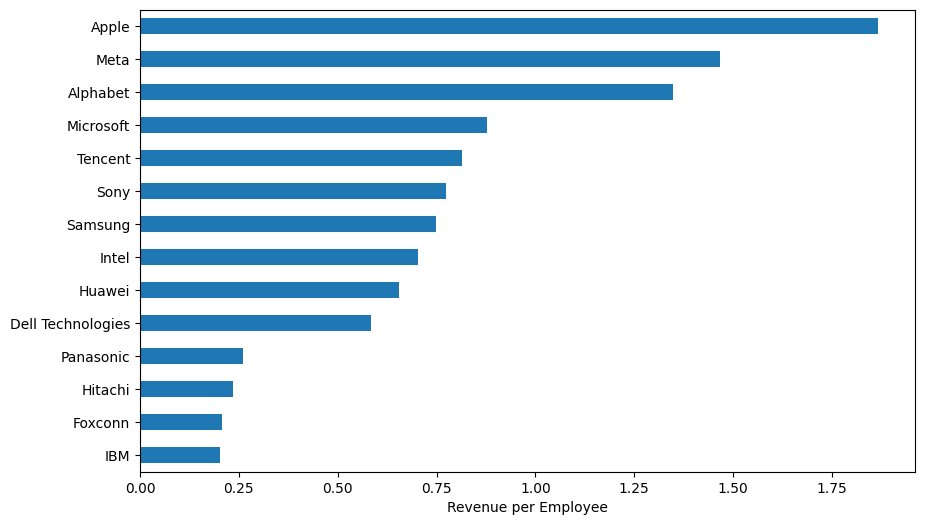

In [19]:
import matplotlib.pyplot as plt

df.sort_values("Revenue per employee")["Revenue per employee"].plot(
    kind="barh", figsize=(10,6)
)
plt.xlabel("Revenue per Employee")
plt.show()

### 🟢 Basic Filtering

#### 1. Show all companies from the USA.

In [20]:
df

,Revenue,Employees,Sector,Founding Date,Country,Revenue per employee
Apple,274515,147000,Consumer Electronics,01-04-1976,USA,1.867449
Samsung,200734,267937,Consumer Electronics,13-01-1969,South Korea,0.749184
Alphabet,182527,135301,Software Services,04-09-1998,USA,1.349044
Foxconn,181945,878429,Chip Manufacturing,20-02-1974,Taiwan,0.207125
Microsoft,143015,163000,Software Services,04-04-1975,USA,0.877393
Huawei,129184,197000,Consumer Electronics,15-09-1987,China,0.655756
Dell Technologies,92224,158000,Consumer Electronics,01-02-1984,USA,0.583696
Meta,85965,58604,Software Services,04-02-2004,USA,1.466879
Sony,84893,109700,Consumer Electronics,07-04-1946,Japan,0.773865
Hitachi,82345,350864,Consumer Electronics,01-01-1910,Japan,0.234692


In [22]:
df[ df['Country'] == 'USA' ][['Country']]

,Country
Apple,USA
Alphabet,USA
Microsoft,USA
Dell Technologies,USA
Meta,USA
Intel,USA
IBM,USA


#### 2. Show all companies in the Software Services sector.

In [27]:
df[ df['Sector'] == "Software Services"][["Sector"]]

,Sector
Alphabet,Software Services
Microsoft,Software Services
Meta,Software Services
IBM,Software Services
Tencent,Software Services


#### 3. Display companies with more than 200,000 employees.

In [32]:
# df[ df['Employees'] > 200000 ][['Employees']]
df.query("Employees > 200000")[['Employees']]

,Employees
Samsung,267937
Foxconn,878429
Hitachi,350864
IBM,364800
Panasonic,243540


#### 4. Find companies whose revenue is greater than 100,000.

In [33]:
# df[ df['Revenue'] > 100000 ][['Revenue']]
df.query("Revenue > 100000")[['Revenue']] 

,Revenue
Apple,274515
Samsung,200734
Alphabet,182527
Foxconn,181945
Microsoft,143015
Huawei,129184


#### 5. Show all companies located in Japan.

In [34]:
df[ df['Country'] == 'Japan' ][['Country']]

,Country
Sony,Japan
Hitachi,Japan
Panasonic,Japan


#### 6. Find companies founded after 1980.

In [35]:
df[ df['Founding Date'] > 1980 ][["Founding Date"]]

TypeError: '>' not supported between instances of 'str' and 'int'

In [37]:
df['Founding Date'] = pd.to_datetime(df['Founding Date'], dayfirst=True)
df[ df['Founding Date'].dt.year > 1980 ][["Founding Date"]]

,Founding Date
Alphabet,1998-09-04
Huawei,1987-09-15
Dell Technologies,1984-02-01
Meta,2004-02-04
Tencent,1998-11-11


### 🟡 Multiple Conditions